# Лабораторная работа 1
команда:

Аббясов Радислам 367038

Егорова Варвара 408575

Ташкинова Татьяна 413084

## 1. Импорт библиотек


In [ ]:
import os
import re
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.integrate import trapezoid

## 2. Подключение данных и поиск нужных файлов


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
muscle_folders = ['на кисти', 'предплечье', 'плечо']

In [ ]:
import os
import numpy as np
import pandas as pd

PATH = '/content/drive/MyDrive/нейро'

os.chdir(PATH)
print("Текущая папка:", os.getcwd())

muscle_folders = ['на кисти', 'предплечье', 'плечо']


def load_muscle_signal(directory):
    if not os.path.isdir(directory):
        print('Папка не найдена:', directory)
        return None, None, None

    signal_files = [
        file_name for file_name in os.listdir(directory)
        if file_name.lower().endswith('.dat')
    ]

    if len(signal_files) == 0:
        print('DAT-файлы не найдены:', directory)
        return None, None, None

    target_signal = None

    for file_name in signal_files:
        if 'EMG' in file_name.upper():
            target_signal = file_name
            break

    if target_signal is None:
        print('EMG-файл не найден:', directory)
        return None, None, None

    full_path = os.path.join(directory, target_signal)

    try:
        raw_signal = np.loadtxt(full_path)

        timestamps = raw_signal[:, 0]
        muscle_activity = raw_signal[:, 1]

        sampling_rate = 1000

        return timestamps, muscle_activity, sampling_rate

    except Exception as error:
        print('Ошибка чтения:', full_path)
        print(error)
        return None, None, None


def collect_emg_files(root_folder):
    records = []

    for zone in muscle_folders:
        zone_path = os.path.join(root_folder, zone)

        if not os.path.isdir(zone_path):
            print('Зона не найдена:', zone_path)
            continue

        actions = [
            action for action in os.listdir(zone_path)
            if os.path.isdir(os.path.join(zone_path, action))
        ]

        for action in actions:
            action_path = os.path.join(zone_path, action)

            dat_files = [
                file_name for file_name in os.listdir(action_path)
                if file_name.lower().endswith('.dat')
            ]

            emg_file = None

            for file_name in dat_files:
                if 'EMG' in file_name.upper():
                    emg_file = file_name
                    break

            if emg_file is None:
                continue

            records.append({
                'zone': zone,
                'action': action,
                'file_name': emg_file,
                'folder_path': action_path,
                'file_path': os.path.join(action_path, emg_file)
            })

    emg_table = pd.DataFrame(records)

    if len(emg_table) > 0:
        emg_table = emg_table.sort_values(
            ['zone', 'action']
        ).reset_index(drop=True)

    return emg_table


emg_files = collect_emg_files(PATH)

print('Найдено EMG-файлов:', len(emg_files))

Текущая папка: /content/drive/MyDrive/нейро
Найдено EMG-файлов: 15


## 3. Чтение одного ЭМГ-сигнала

Файлы имеют табличный вид: первая колонка — время, вторая — значение ЭМГ. Частота дискретизации вычисляется автоматически по шагу времени.

In [ ]:
def read_emg_dat(file_path):
    df = pd.read_csv(
        file_path,
        sep=r'\s+',
        header=None,
        engine='python'
    )

    df = df.dropna(axis=1, how='all')

    if df.shape[1] < 2:
        raise ValueError(f'Недостаточно колонок в файле: {file_path}')

    time = df.iloc[:, 0].astype(float).to_numpy()
    emg = df.iloc[:, 1].astype(float).to_numpy()

    # Удаление некорректных значений
    valid_mask = np.isfinite(time) & np.isfinite(emg)

    time = time[valid_mask]
    emg = emg[valid_mask]

    # Сортировка по времени
    sorting_order = np.argsort(time)

    time = time[sorting_order]
    emg = emg[sorting_order]

    # Частота дискретизации
    dt = np.diff(time)
    dt = dt[dt > 0]

    fs = 1 / np.median(dt)

    return time, emg, fs


# Проверка первого EMG-файла
sample_row = emg_files.iloc[0]

t, x, fs = read_emg_dat(sample_row['file_path'])

print('Зона:', sample_row['zone'])
print('Действие:', sample_row['action'])
print('Файл:', sample_row['file_name'])

print('Количество точек:', len(x))
print('Частота дискретизации:', round(fs, 2), 'Гц')
print('Длительность сигнала:', round(t[-1] - t[0], 2), 'с')

Зона: на кисти
Действие: 1,2 - нажимать
Файл: 18_2_2026_15_0_20_EMG.dat
Количество точек: 3623
Частота дискретизации: 243.12 Гц
Длительность сигнала: 11.35 с


## 4. Функции предобработки

1. нормализация времени от нуля;
2. обрезка первых секунд записи;
3. робастное подавление выбросов через MAD;
4. полосовая фильтрация ЭМГ;
5. опциональный notch-фильтр 50 Гц;
6. полноволновое выпрямление;
7. сглаживание выпрямленного сигнала для получения огибающей.

In [ ]:
def normalize_time(time):
    return time - time[0]


def crop_signal(time, signal, start_sec=2.0, end_sec=0.0):
    time = normalize_time(time)
    keep = time >= start_sec
    if end_sec > 0:
        keep &= time <= (time[-1] - end_sec)
    return time[keep] - time[keep][0], signal[keep]


def replace_outliers_mad(signal, threshold=8.0):
    """Заменяет редкие выбросы интерполяцией по нормальным точкам."""
    x = np.asarray(signal, dtype=float).copy()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return x

    robust_z = 0.6745 * (x - med) / mad
    bad = np.abs(robust_z) > threshold

    if bad.any() and (~bad).sum() > 2:
        idx = np.arange(len(x))
        x[bad] = np.interp(idx[bad], idx[~bad], x[~bad])
    return x


def butter_filter(x, fs, low=None, high=None, order=4):
    nyq = fs / 2

    if low is not None and high is not None:
        high = min(high, nyq * 0.95)
        low = max(low, 0.01)
        b, a = butter(order, [low / nyq, high / nyq], btype='bandpass')
    elif low is not None:
        low = max(low, 0.01)
        b, a = butter(order, low / nyq, btype='highpass')
    elif high is not None:
        high = min(high, nyq * 0.95)
        b, a = butter(order, high / nyq, btype='lowpass')
    else:
        return x

    return filtfilt(b, a, x)


def notch_50hz(x, fs, freq=50.0, quality=30):
    """Подавляет сетевую наводку 50 Гц, если частота дискретизации позволяет."""
    if fs / 2 <= freq:
        return x
    b, a = iirnotch(w0=freq / (fs / 2), Q=quality)
    return filtfilt(b, a, x)


def process_emg(time, emg, fs,
                crop_start=2.0,
                crop_end=0.0,
                band_low=20.0,
                band_high=250.0,
                envelope_cutoff=8.0,
                use_notch=True):
    time_c, raw_c = crop_signal(time, emg, start_sec=crop_start, end_sec=crop_end)

    clean = replace_outliers_mad(raw_c, threshold=8.0)
    centered = clean - np.median(clean)

    filtered = butter_filter(centered, fs, low=band_low, high=band_high, order=4)
    if use_notch:
        filtered = notch_50hz(filtered, fs)

    rectified = np.abs(filtered)
    envelope = butter_filter(rectified, fs, high=envelope_cutoff, order=4)
    envelope = np.maximum(envelope, 0)

    return {
        'time': time_c,
        'raw': raw_c,
        'clean': clean,
        'filtered': filtered,
        'rectified': rectified,
        'envelope': envelope,
        'fs': fs
    }

## 5. Визуализация этапов обработки



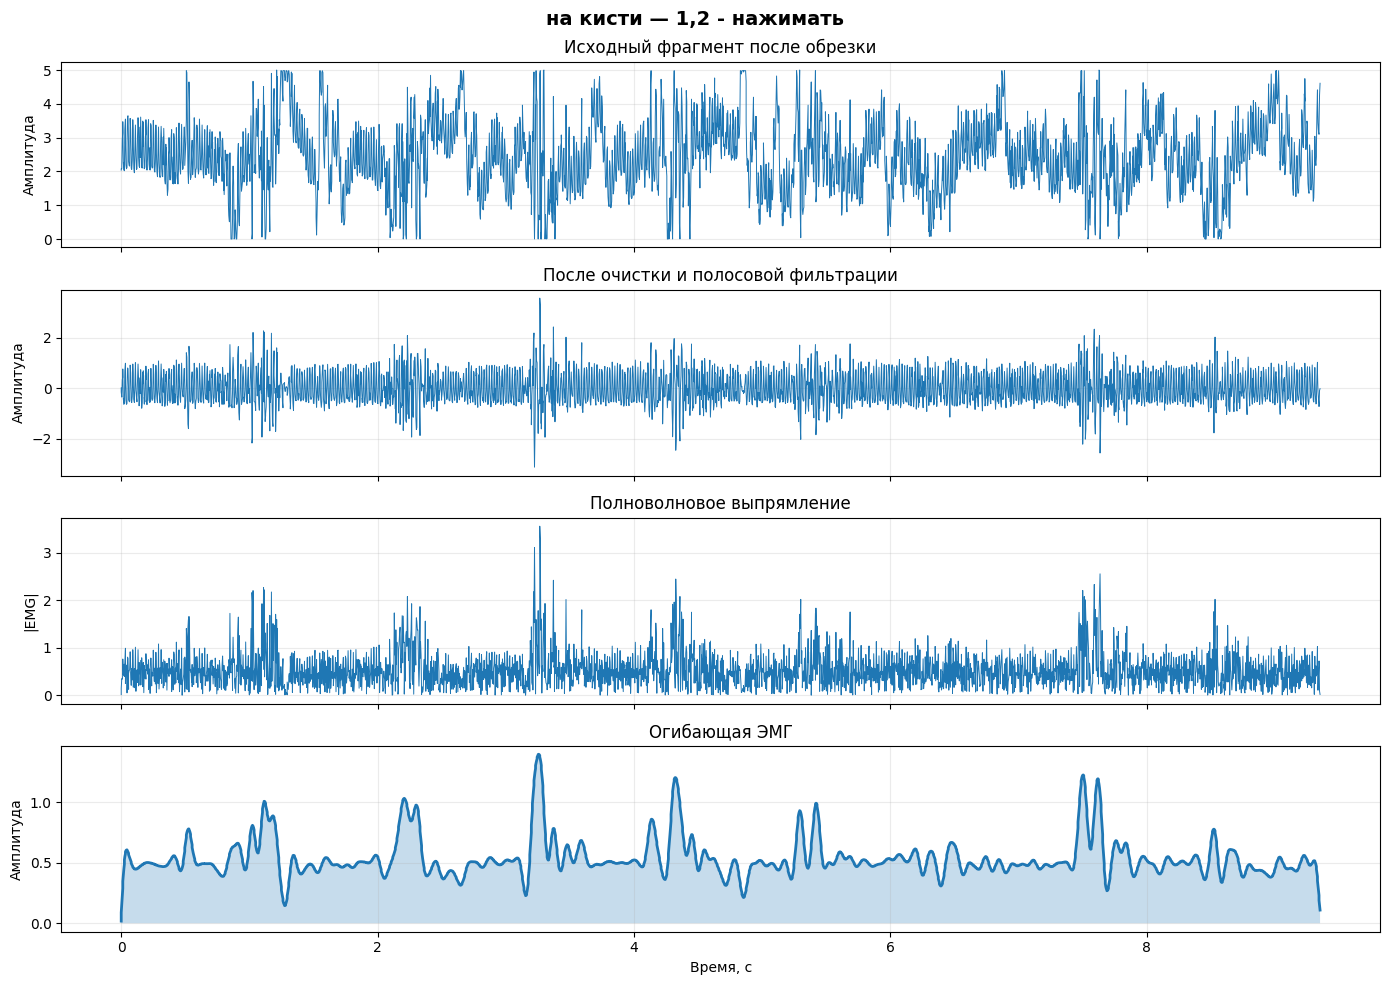

In [ ]:
def plot_processing_diagnostics(proc, title=''):
    time = proc['time']

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(time, proc['raw'], linewidth=0.7)
    axes[0].set_title('Исходный фрагмент после обрезки')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(alpha=0.25)

    axes[1].plot(time, proc['filtered'], linewidth=0.7)
    axes[1].set_title('После очистки и полосовой фильтрации')
    axes[1].set_ylabel('Амплитуда')
    axes[1].grid(alpha=0.25)

    axes[2].plot(time, proc['rectified'], linewidth=0.7)
    axes[2].set_title('Полноволновое выпрямление')
    axes[2].set_ylabel('|EMG|')
    axes[2].grid(alpha=0.25)

    axes[3].plot(time, proc['envelope'], linewidth=2)
    axes[3].fill_between(time, 0, proc['envelope'], alpha=0.25)
    axes[3].set_title('Огибающая ЭМГ')
    axes[3].set_xlabel('Время, с')
    axes[3].set_ylabel('Амплитуда')
    axes[3].grid(alpha=0.25)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Посмотрим обработку первого сигнала
proc_sample = process_emg(t, x, fs)
plot_processing_diagnostics(proc_sample, f"{sample_row['zone']} — {sample_row['action']}")

## 8. Расчёт параметров ЭМГ


Используемые параметры ЭМГ

Для оценки мышечной активности были рассчитаны следующие характеристики:

Максимальная амплитуда — отражает пиковую силу мышечного сокращения;
Средняя амплитуда — характеризует средний уровень активации мышцы;
RMS (Root Mean Square) — отражает энергетическую мощность сигнала и среднюю интенсивность сокращения;
iEMG — интегральная электромиография, соответствующая площади под огибающей сигнала;
Медианная амплитуда — показывает центральное значение распределения амплитуд;
Peak-to-average ratio — отношение максимальной амплитуды к средней, характеризующее выраженность пиков активности.

In [ ]:
from scipy.integrate import trapezoid

def calculate_emg_features(processed_signal):
    time = processed_signal['time']
    envelope = processed_signal['envelope']

    # Максимальная амплитуда
    peak_amplitude = np.max(envelope)

    # Средняя амплитуда
    average_amplitude = np.mean(envelope)

    # Интегральная ЭМГ
    integrated_emg = trapezoid(envelope, time)

    # Среднеквадратичное значение
    rms_value = np.sqrt(np.mean(envelope ** 2))

    # Медианная амплитуда
    median_value = np.median(envelope)

    # Отношение пика к среднему уровню
    if average_amplitude > 0:
        peak_ratio = peak_amplitude / average_amplitude
    else:
        peak_ratio = 0

    metrics = {
        'max_amplitude': peak_amplitude,
        'mean_amplitude': average_amplitude,
        'iemg': integrated_emg,
        'rms': rms_value,
        'median_amplitude': median_value,
        'peak_to_average': peak_ratio
    }

    return metrics

## 9. Полная обработка всех файлов

Все ЭМГ-записи обрабатываются одинаковым способом. Результаты сохраняются в таблицу, а сами обработанные сигналы — в словарь `processed_signals` для последующей визуализации.

In [ ]:
processed_signals = {}
metric_rows = []
errors = []

for i, row in emg_files.iterrows():
    try:
        time, emg, fs = read_emg_dat(row['file_path'])
        proc = process_emg(time, emg, fs)
        metrics = calculate_emg_features(proc)

        key = f"{row['zone']} | {row['action']}"
        processed_signals[key] = proc

        metric_rows.append({
            'zone': row['zone'],
            'action': row['action'],
            'file_name': row['file_name'],
            'fs': fs,
            **metrics
        })

    except Exception as e:
        errors.append((row['file_path'], str(e)))

results = pd.DataFrame(metric_rows)

print('Успешно обработано файлов:', len(results))
print('Ошибок:', len(errors))

display(results.round(4))

if errors:
    print('Файлы с ошибками:')
    for path, err in errors:
        print(path, '->', err)

Успешно обработано файлов: 15
Ошибок: 0


,zone,action,file_name,fs,max_amplitude,mean_amplitude,iemg,rms,median_amplitude,peak_to_average
0,на кисти,"1,2 - нажимать",18_2_2026_15_0_20_EMG.dat,243.1203,1.3973,0.5399,5.0528,0.5653,0.4991,2.5881
1,на кисти,пальцы,18_2_2026_15_3_19_EMG.dat,243.1481,0.9116,0.4312,5.0280,0.4457,0.4055,2.1140
2,на кисти,по кругу,18_2_2026_15_2_15_EMG.dat,243.1197,0.9454,0.4222,5.2460,0.4467,0.3769,2.2393
3,на кисти,поднимание кисти,18_2_2026_15_4_38_EMG.dat,243.1197,0.5808,0.1643,1.5516,0.1853,0.1333,3.5342
4,на кисти,сгибать палец,18_2_2026_15_6_1_EMG.dat,243.1481,0.4635,0.0700,0.6455,0.0818,0.0584,6.6194
5,плечо,в сторону,18_2_2026_15_11_40_EMG.dat,243.1197,0.7270,0.1859,1.5474,0.2204,0.1529,3.9113
6,плечо,вращение,18_2_2026_15_15_52_EMG.dat,243.1481,1.3797,0.1409,1.2065,0.2133,0.0878,9.7886
7,плечо,кручение,18_2_2026_15_12_44_EMG.dat,243.1481,1.0226,0.1943,1.7181,0.2575,0.1261,5.2625
8,плечо,рюкзак,18_2_2026_15_14_40_EMG.dat,243.1759,0.4998,0.1952,1.6928,0.2079,0.1897,2.5598
9,плечо,сгибание вертикально,18_2_2026_15_10_50_EMG.dat,243.1759,0.4448,0.1420,1.2826,0.1512,0.1312,3.1331


## 10. Сравнение движений внутри каждой зоны



In [ ]:
def add_zone_scores(df):
    df = df.copy()

    score_cols = ['rms', 'iemg', 'max_amplitude']

    for col in score_cols:
        norm_col = col + '_norm'

        df[norm_col] = df.groupby('zone')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
            if x.max() != x.min()
            else 0
        )

    df['total_score'] = df[
        ['rms_norm', 'iemg_norm', 'max_amplitude_norm']
    ].mean(axis=1)

    return df


ranked = add_zone_scores(results)

ranked = ranked.sort_values(
    ['zone', 'total_score'],
    ascending=[True, False]
).reset_index(drop=True)


display(
    ranked[
        [
            'zone',
            'action',
            'max_amplitude',
            'mean_amplitude',
            'rms',
            'iemg',
            'median_amplitude',
            'peak_to_average',
            'total_score'
        ]
    ].round(4)
)


best_by_zone = ranked.loc[
    ranked.groupby('zone')['total_score'].idxmax()
].sort_values('zone')


print('Лучшее движение для каждой зоны регистрации:')

display(
    best_by_zone[
        [
            'zone',
            'action',
            'total_score',
            'rms',
            'iemg',
            'max_amplitude'
        ]
    ].round(4)
)

,zone,action,max_amplitude,mean_amplitude,rms,iemg,median_amplitude,peak_to_average,total_score
0,на кисти,"1,2 - нажимать",1.3973,0.5399,0.5653,5.0528,0.4991,2.5881,0.9860
1,на кисти,по кругу,0.9454,0.4222,0.4467,5.2460,0.3769,2.2393,0.7569
2,на кисти,пальцы,0.9116,0.4312,0.4457,5.0280,0.4055,2.1140,0.7284
3,на кисти,поднимание кисти,0.5808,0.1643,0.1853,1.5516,0.1333,3.5342,0.1789
4,на кисти,сгибать палец,0.4635,0.0700,0.0818,0.6455,0.0584,6.6194,0.0000
5,плечо,кручение,1.0226,0.1943,0.2575,1.7181,0.1261,5.2625,0.8727
6,плечо,в сторону,0.7270,0.1859,0.2204,1.5474,0.1529,3.9113,0.5399
7,плечо,вращение,1.3797,0.1409,0.2133,1.2065,0.0878,9.7886,0.5282
8,плечо,рюкзак,0.4998,0.1952,0.2079,1.6928,0.1897,2.5598,0.5144
9,плечо,сгибание вертикально,0.4448,0.1420,0.1512,1.2826,0.1312,3.1331,0.0496


Лучшее движение для каждой зоны регистрации:


,zone,action,total_score,rms,iemg,max_amplitude
0,на кисти,"1,2 - нажимать",0.9860,0.5653,5.0528,1.3973
5,плечо,кручение,0.8727,0.2575,1.7181,1.0226
10,предплечье,4 - звездочка жим,0.9471,0.2729,1.9721,0.6737


## 11. Графики сравнения параметров

Ниже строятся сводные графики по зонам регистрации. Они позволяют увидеть, какие движения дают максимальную электрическую активность мышцы.

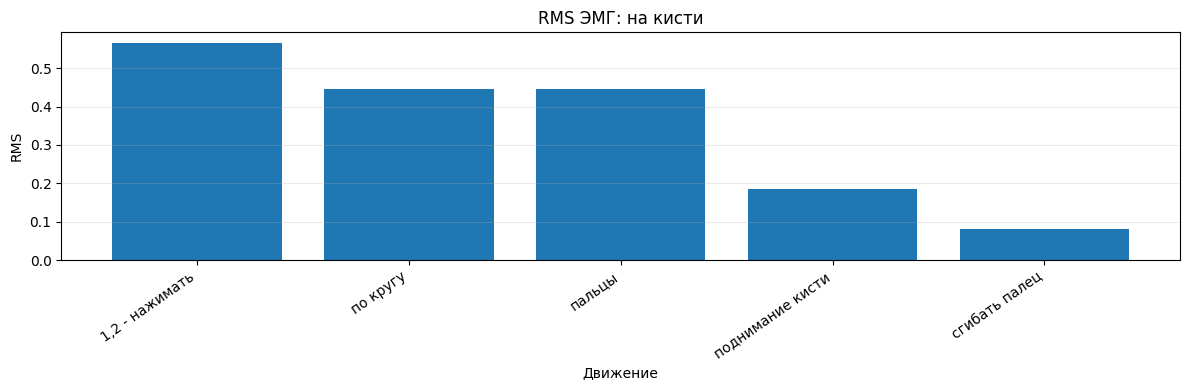

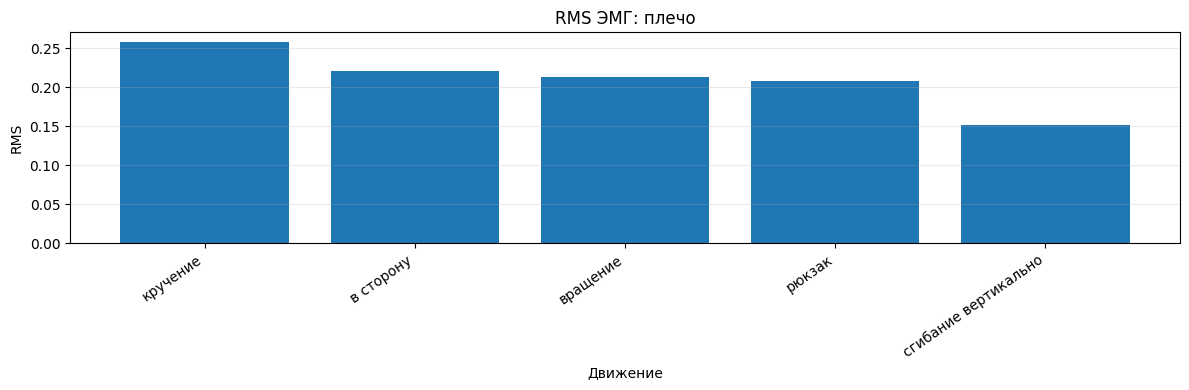

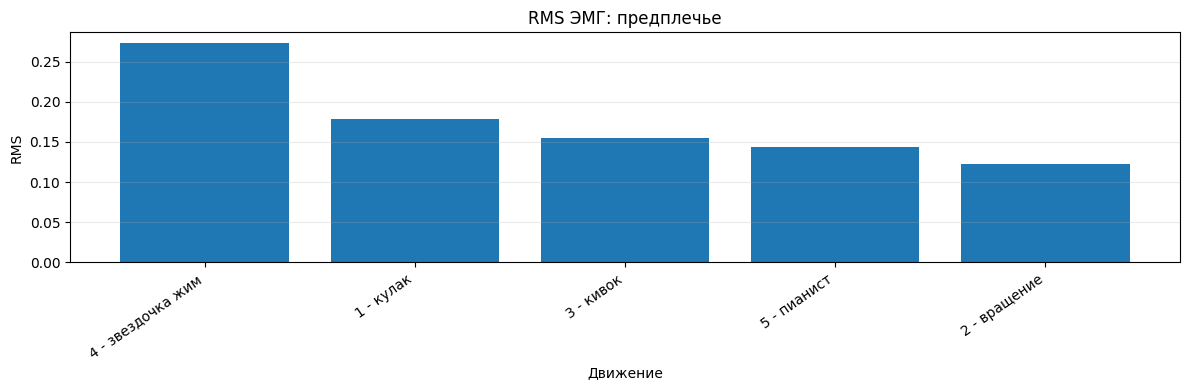

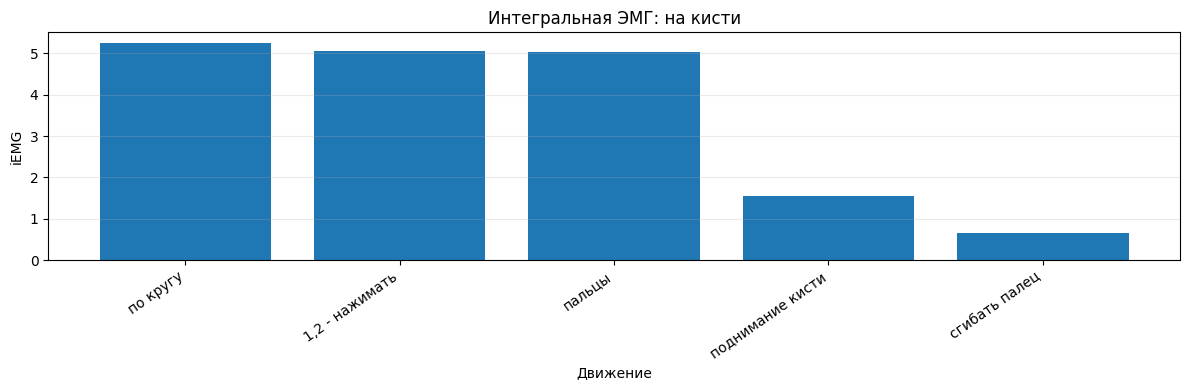

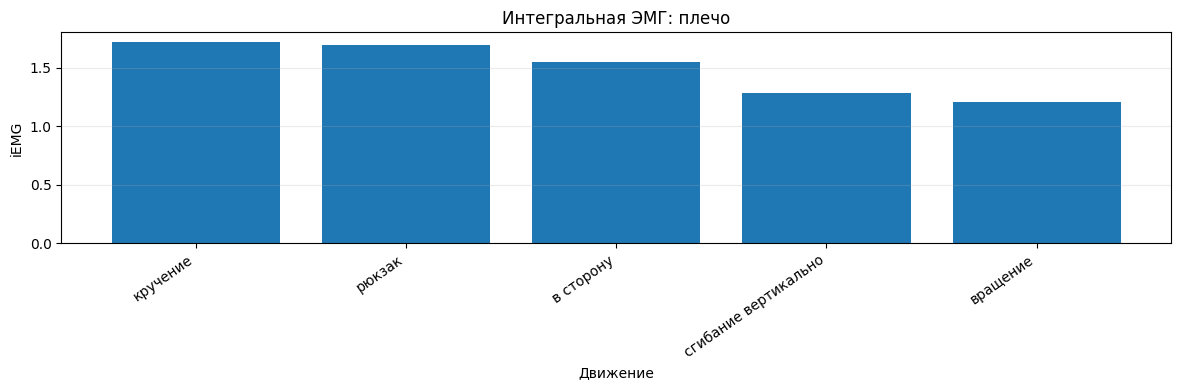

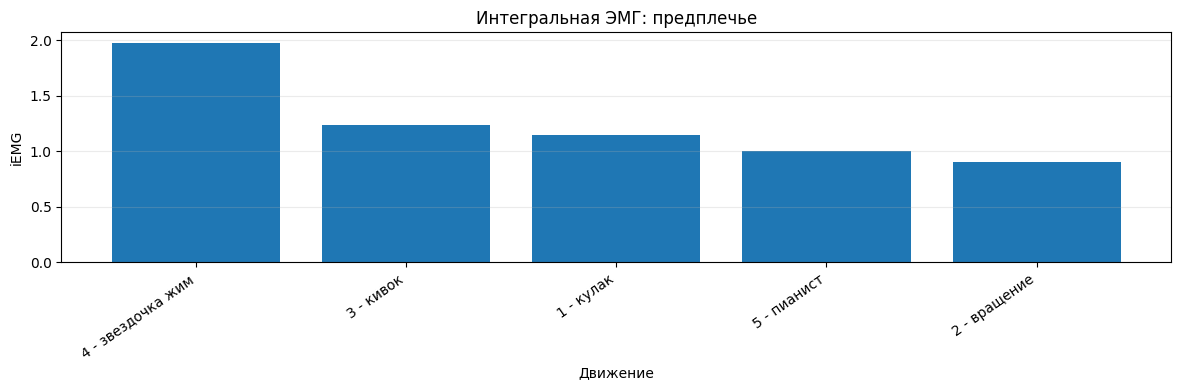

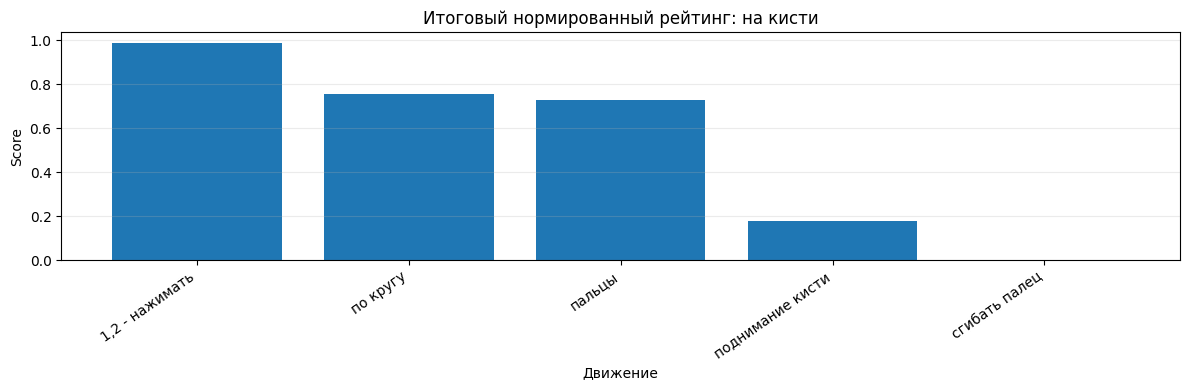

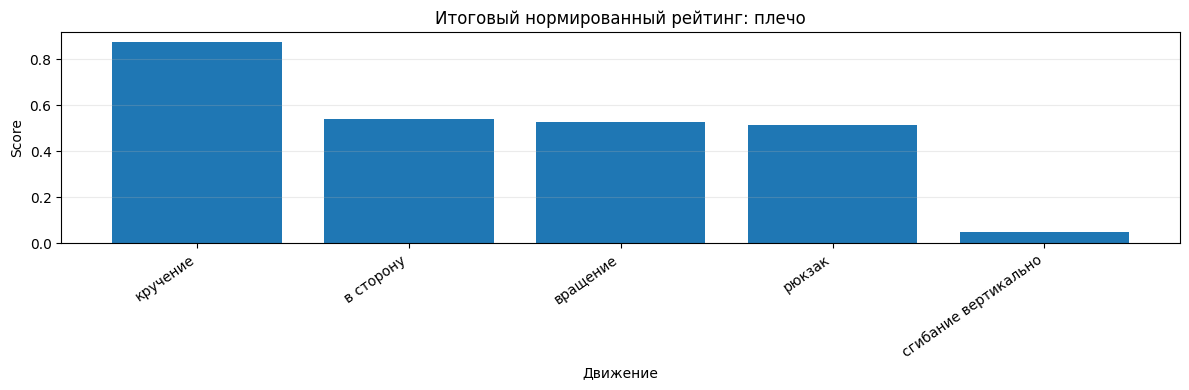

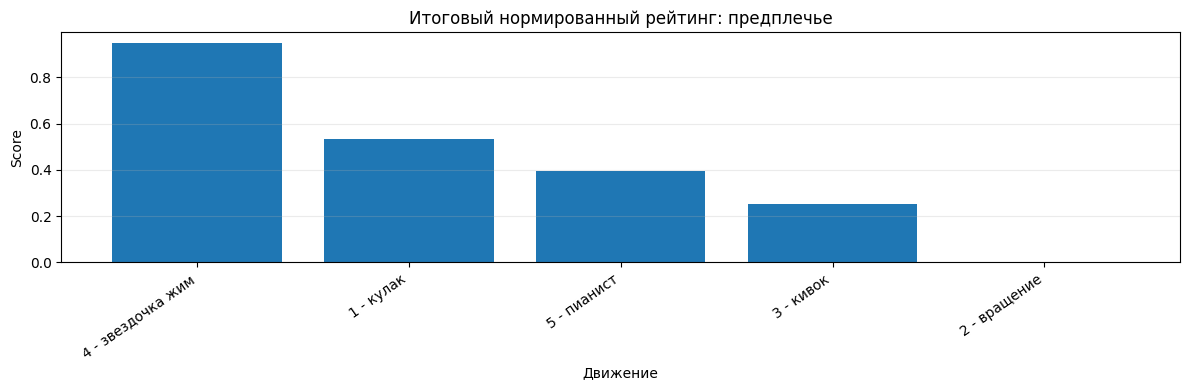

In [ ]:
def plot_metric_by_zone(df, metric, title, ylabel):
    zones = df['zone'].unique()

    for zone in zones:
        part = df[df['zone'] == zone].sort_values(metric, ascending=False)

        plt.figure(figsize=(12, 4))
        plt.bar(part['action'], part[metric])
        plt.title(f'{title}: {zone}')
        plt.ylabel(ylabel)
        plt.xlabel('Движение')
        plt.xticks(rotation=35, ha='right')
        plt.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()

plot_metric_by_zone(ranked, 'rms', 'RMS ЭМГ', 'RMS')
plot_metric_by_zone(ranked, 'iemg', 'Интегральная ЭМГ', 'iEMG')
plot_metric_by_zone(ranked, 'total_score', 'Итоговый нормированный рейтинг', 'Score')

## 12. Детальный график лучшего движения в каждой зоне

Для каждого лучшего движения выводится огибающая ЭМГ, порог активного участка и значения основных метрик.

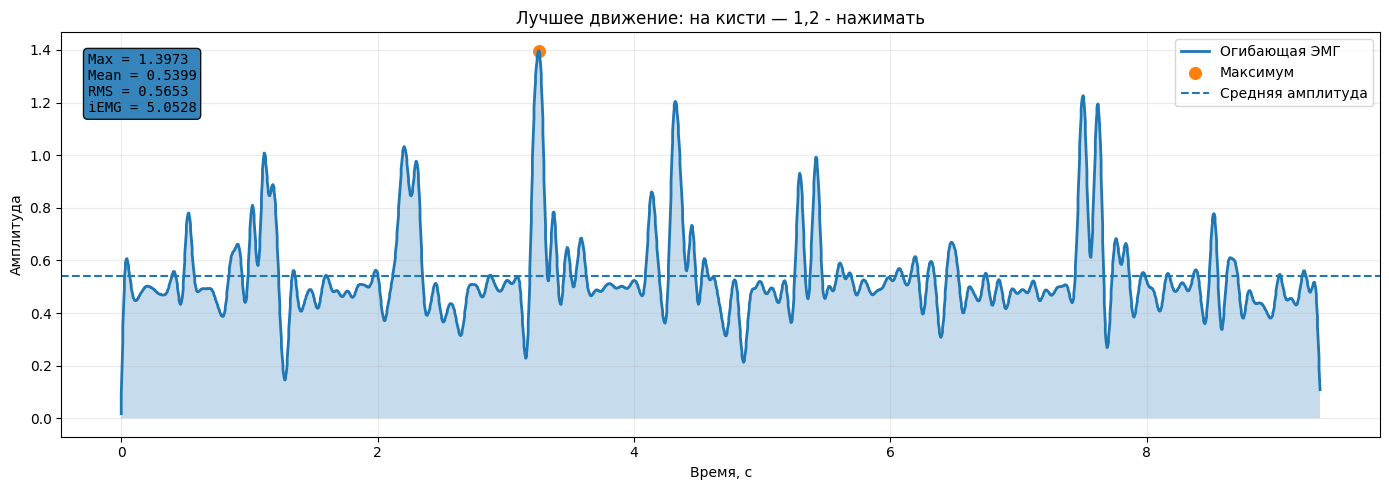

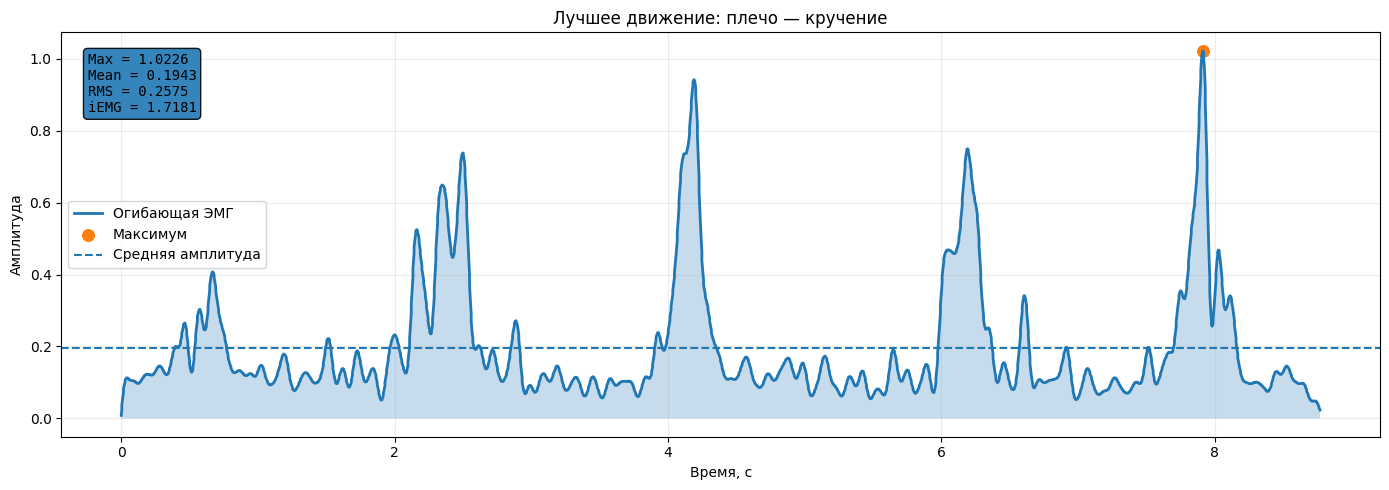

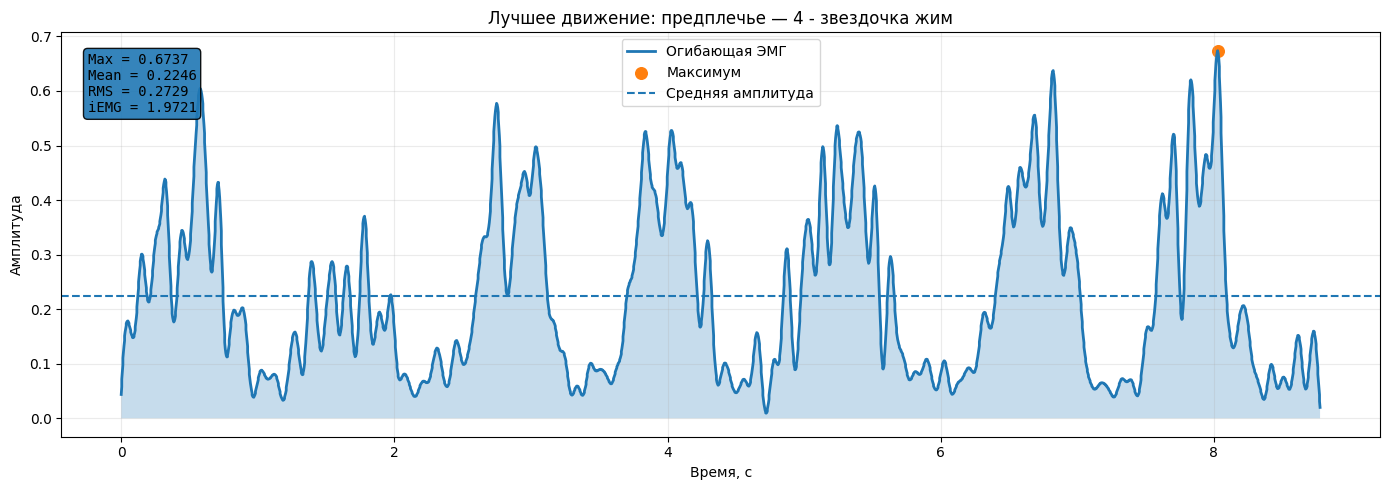

In [ ]:
def plot_best_signal(row):
    key = f"{row['zone']} | {row['action']}"
    proc = processed_signals[key]

    time = proc['time']
    env = proc['envelope']

    plt.figure(figsize=(14, 5))

    plt.plot(time, env, linewidth=2, label='Огибающая ЭМГ')
    plt.fill_between(time, 0, env, alpha=0.25)

    max_idx = np.argmax(env)
    plt.scatter(
        time[max_idx],
        env[max_idx],
        s=70,
        label='Максимум'
    )

    plt.axhline(
        row['mean_amplitude'],
        linestyle='--',
        linewidth=1.5,
        label='Средняя амплитуда'
    )

    text = (
        f"Max = {row['max_amplitude']:.4f}\n"
        f"Mean = {row['mean_amplitude']:.4f}\n"
        f"RMS = {row['rms']:.4f}\n"
        f"iEMG = {row['iemg']:.4f}"
    )

    plt.text(
        0.02,
        0.95,
        text,
        transform=plt.gca().transAxes,
        va='top',
        family='monospace',
        bbox=dict(boxstyle='round', alpha=0.9)
    )

    plt.title(f"Лучшее движение: {row['zone']} — {row['action']}")
    plt.xlabel('Время, с')
    plt.ylabel('Амплитуда')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


for _, row in best_by_zone.iterrows():
    plot_best_signal(row)

### Вывод

В ходе лабораторной работы были обработаны ЭМГ-сигналы, зарегистрированные с трёх зон: кисть, предплечье и плечо. Всего было найдено и успешно обработано 15 EMG-файлов, ошибок при обработке не возникло.

Для каждого сигнала была выполнена предобработка: нормализация времени, обрезка начального участка, подавление выбросов, полосовая фильтрация, выпрямление и построение огибающей ЭМГ. После этого были рассчитаны основные параметры мышечной активности: максимальная амплитуда, средняя амплитуда, RMS, iEMG, медианная амплитуда и отношение максимума к среднему значению.

По итоговому рейтингу наибольший электрический эффект показали следующие движения:

- для зоны **на кисти** — **1,2 - нажимать**;
- для зоны **плечо** — **кручение**;
- для зоны **предплечье** — **4 - звездочка жим**.

Для кисти движение «1,2 - нажимать» показало наибольшие значения RMS и максимальной амплитуды, что говорит о выраженной мышечной активации. Для плеча наиболее активным оказалось движение «кручение», так как оно имело высокий общий рейтинг по RMS, iEMG и максимальной амплитуде. Для предплечья максимальный эффект наблюдался при движении «4 - звездочка жим», что связано с наибольшей суммарной активностью мышцы и высоким RMS.

Таким образом, обработка ЭМГ позволила сравнить разные движения между собой и определить, какие из них вызывают наиболее сильную электрическую активность мышц в каждой зоне регистрации.